In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from sklearn.utils import shuffle

from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = '/content/drive/MyDrive/CapStone_Tomatao/new/actual dataset/train'
test = '/content/drive/MyDrive/CapStone_Tomatao/new/actual dataset/test'
val = '/content/drive/MyDrive/CapStone_Tomatao/new/actual dataset/val'

In [4]:

img_height = 224
img_width = 224
batch_size = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train,
    seed=42,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = True,
    label_mode = 'binary'
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test,
    seed = 42,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    label_mode = 'binary'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val,
    seed=42,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    label_mode = 'binary'
)

Found 6650 files belonging to 2 classes.
Found 1425 files belonging to 2 classes.
Found 1425 files belonging to 2 classes.


In [5]:
train_ds = train_ds_raw
test_ds = test_ds_raw
val_ds = val_ds_raw

In [6]:
CLASS_NAMES = train_ds.class_names
print(CLASS_NAMES)
print(len(CLASS_NAMES))
print(test_ds.class_names)
print(val_ds.class_names)

['Non_Tomato', 'tomato']
2
['Non_Tomato', 'tomato']
['Non_Tomato', 'tomato']


In [7]:
for image, label in train_ds.take(1):
  print(f'min pixel: {image.numpy().min()}')
  print(f'max pixel: {image.numpy().max()}')
  print(f'label type: {label.dtype}')
  print(f'label shape: {label.shape}')

min pixel: 0.0
max pixel: 255.0
label type: <dtype: 'float32'>
label shape: (32, 1)


In [8]:
# if shape is (32, 1) then run this cell

train_ds = train_ds.map(lambda x, y: (x, tf.reshape(y, [-1])))
test_ds = test_ds.map(lambda x, y: (x, tf.reshape(y, [-1])))
val_ds = val_ds.map(lambda x, y: (x, tf.reshape(y, [-1])))

In [9]:
for image, label in train_ds.take(1):
  print(f'min pixel: {image.numpy().min()}')
  print(f'max pixel: {image.numpy().max()}')
  print(f'label type: {label.dtype}')
  print(f'label shape: {label.shape}')

min pixel: 0.0
max pixel: 255.0
label type: <dtype: 'float32'>
label shape: (32,)


In [10]:
print(f'Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}')
print(f'Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}')
print(f'Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}')

Train batches: 208
Test batches: 45
Val batches: 45


In [11]:
total_train = 0
tomato_count = 0

for image, label in train_ds:
  total_train += len(label)
  tomato_count += tf.reduce_sum(tf.cast(label, tf.int32)).numpy()

print(f'Total train samples: {total_train}')
print(f'Tomato: {tomato_count}, non_tomato: {total_train - tomato_count}')

Total train samples: 6650
Tomato: 3150, non_tomato: 3500


In [ ]:
total_test = 0
cocoa_count = 0

for image, label in test_ds:
  total_test += len(label)
  cocoa_count += tf.reduce_sum(tf.cast(label, tf.int32)).numpy()

print(f'Total test samples: {total_test}')
print(f'cocoa: {cocoa_count}, non_cocoa: {total_test - cocoa_count}')

In [ ]:
total_val = 0
cocoa_count = 0

for image, label in val_ds:
  total_val += len(label)
  cocoa_count += tf.reduce_sum(tf.cast(label, tf.int32)).numpy()

print(f'Total val samples: {total_val}')
print(f'cocoa: {cocoa_count}, non_cocoa: {total_val - cocoa_count}')

Image shape: (32, 224, 224, 3)


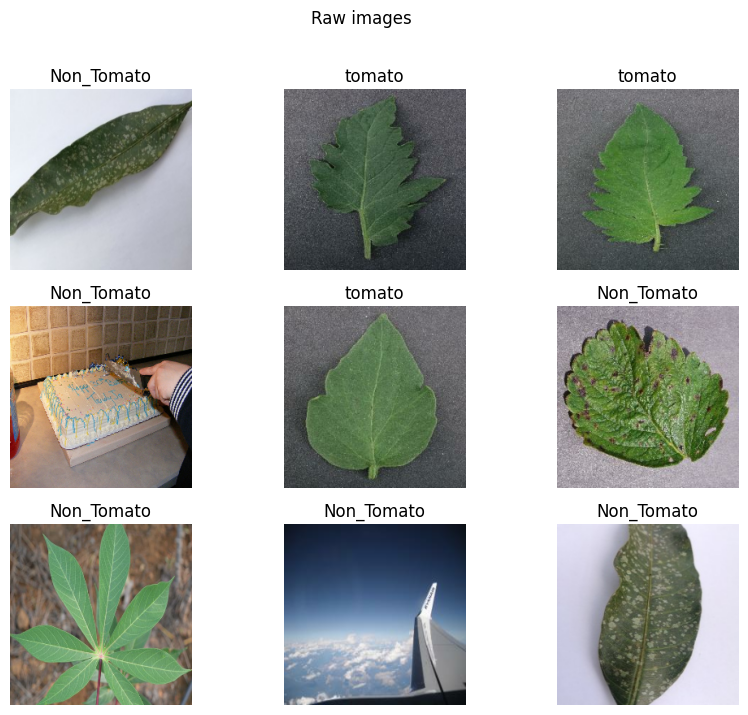

In [12]:
for images, labels in train_ds.take(1):
  print(f'Image shape:', images.shape)
  plt.figure(figsize=(10,8))
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(CLASS_NAMES[int(labels[i])])
    plt.axis('off')
  plt.suptitle('Raw images')
  plt.show()

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

In [12]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

In [13]:
base_model = EfficientNetB0(include_top=False, weights='imagenet',
                            input_shape=(img_height, img_width, 3))

base_model.trainable = False
print(f'Base model layers: {len(base_model.layers)}')
print(f'Trainable parameters: {len(base_model.trainable_variables)}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model layers: 238
Trainable parameters: 0


In [14]:
@tf.keras.utils.register_keras_serializable()
class EfficientNetPreprocessing(tf.keras.layers.Layer):
  def call(self, x):
    return tf.keras.applications.efficientnet.preprocess_input(x)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    EfficientNetPreprocessing(),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficient_net_preprocessing     │ (None, 224, 224, 3)    │             0 │
│ (EfficientNetPreprocessing)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [15]:
data_augmentation.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
phase_1 = '/content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase1.keras'

checkpoint_1 = ModelCheckpoint(
    filepath=phase_1,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
print('Training')

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_1, early_stopping, reduce_lr]
)

print()
print('Training finished')

Training
Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8680 - loss: 0.2925
Epoch 1: val_loss improved from None to 0.09299, saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase1.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 1822s 3s/step - accuracy: 0.9316 - loss: 0.1718 - val_accuracy: 0.9881 - val_loss: 0.0930 - learning_rate: 1.0000e-04
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9801 - loss: 0.0663
Epoch 2: val_loss improved from 0.09299 to 0.03579, saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase1.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.9830 - loss: 0.0587 - val_accuracy: 0.9916 - val_loss: 0.0358 - learning_rate: 1.0000e-04
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 7

In [19]:
history1.history['val_loss']

[0.0929863452911377,
 0.03578551486134529,
 0.029475940391421318,
 0.022080598399043083,
 0.021251020953059196,
 0.018214352428913116,
 0.016970010474324226,
 0.015984073281288147,
 0.014191849157214165,
 0.01430817972868681,
 0.013573371805250645,
 0.012675145640969276,
 0.01276992354542017,
 0.012642739340662956,
 0.012090180069208145,
 0.01190441194921732,
 0.012715824879705906,
 0.01138885598629713,
 0.011249988339841366,
 0.01096918061375618,
 0.010908445343375206,
 0.010417896322906017,
 0.011004649102687836,
 0.010690554976463318,
 0.010524842888116837,
 0.01068160030990839,
 0.010283100418746471,
 0.010336737148463726,
 0.010580064728856087,
 0.010303723625838757]

In [20]:
def plot_history(history, title):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(acc)+1)

  plt.figure(figsize=(14,5))

  plt.subplot(1,2,1)
  plt.plot(epochs, acc, 'g-o', label='Training accuracy')
  plt.plot(epochs, val_acc, 'b-o', label='Validation accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs, loss, 'g-o', label='Training loss')
  plt.plot(epochs, val_loss, 'b-o', label='Validation loss')
  plt.title('loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.suptitle(title)
  plt.tight_layout()
  plt.show()

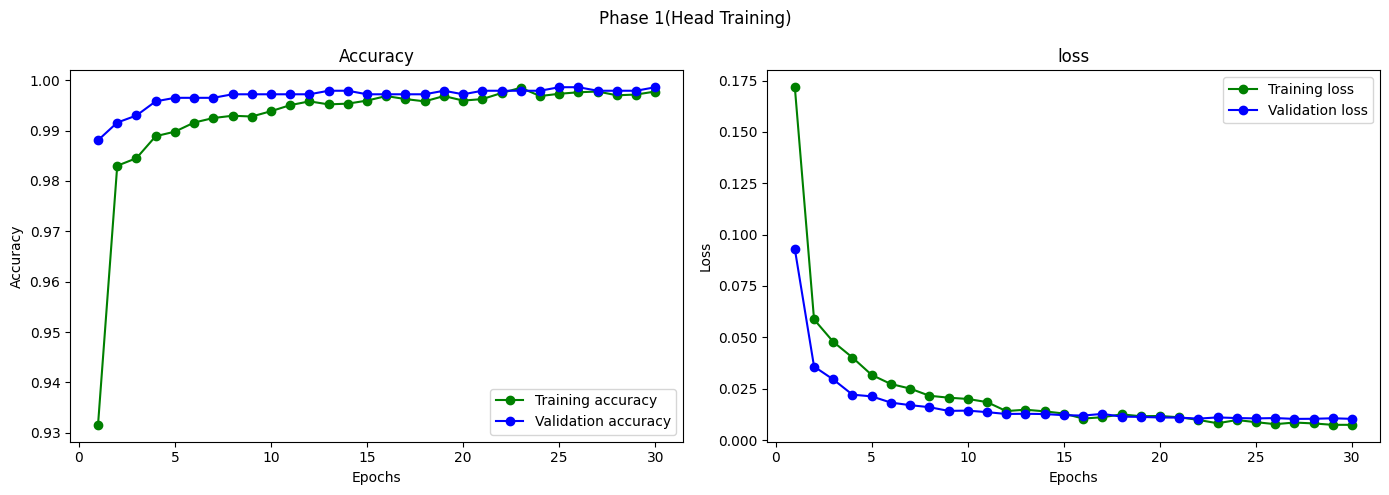

In [21]:
plot_history(history1, 'Phase 1(Head Training)')

In [22]:
import json

history_data_1 = {
    'accuracy': history1.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'],
    'loss': history1.history['loss'],
    'val_loss': history1.history['val_loss']
}

with open('/content/drive/MyDrive/CapStone_Tomatao/new/models/history1.json', 'w') as f:
    json.dump(history_data_1, f)

print('History saved')

History saved


In [23]:
with open('/content/drive/MyDrive/CapStone_Tomatao/new/models/history1.json', 'r') as f:
    history_data = json.load(f)

In [24]:
model = tf.keras.models.load_model(phase_1)
model.get_layer(base_model.name).trainable = True

for layer in model.get_layer(base_model.name).layers[:-30]:
  layer.trainable = False

print(f'Total Trainable parameters: {len(model.trainable_variables)}')

base = model.get_layer(base_model.name)
trainables = [l.name for l in base.layers if l.trainable]
non_trainables = [l.name for l in base.layers if not l.trainable]

print(f'Frozen layers:   {len(non_trainables)}')
print(f'Trainable layers: {len(trainables)}')
print(f'Trainable layer names: {trainables}')

for layer in model.get_layer(base_model.name).layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

Total Trainable parameters: 34
Frozen layers:   208
Trainable layers: 30
Trainable layer names: ['block6d_expand_bn', 'block6d_expand_activation', 'block6d_dwconv', 'block6d_bn', 'block6d_activation', 'block6d_se_squeeze', 'block6d_se_reshape', 'block6d_se_reduce', 'block6d_se_expand', 'block6d_se_excite', 'block6d_project_conv', 'block6d_project_bn', 'block6d_drop', 'block6d_add', 'block7a_expand_conv', 'block7a_expand_bn', 'block7a_expand_activation', 'block7a_dwconv', 'block7a_bn', 'block7a_activation', 'block7a_se_squeeze', 'block7a_se_reshape', 'block7a_se_reduce', 'block7a_se_expand', 'block7a_se_excite', 'block7a_project_conv', 'block7a_project_bn', 'top_conv', 'top_bn', 'top_activation']


In [25]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
phase_2 = '/content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase2.keras'

checkpoint_2 = ModelCheckpoint(
    filepath=phase_2,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [27]:
print('Training')

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_2, early_stopping, reduce_lr]
)

print()
print('Training finished')

Training
Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9977 - loss: 0.0060
Epoch 1: val_loss improved from None to 0.00957, saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase2.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9986 - val_loss: 0.0096 - learning_rate: 1.0000e-05
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9965 - loss: 0.0083
Epoch 2: val_loss improved from 0.00957 to 0.00949, saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase2.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.9986 - val_loss: 0.0095 - learning_rate: 1.0000e-05
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s

In [28]:
history2.history['val_loss']

[0.009571594186127186,
 0.00948524009436369,
 0.009641028009355068,
 0.010030856356024742,
 0.009883550927042961,
 0.009735501371324062,
 0.009768962860107422,
 0.00968420971184969,
 0.009779230691492558]

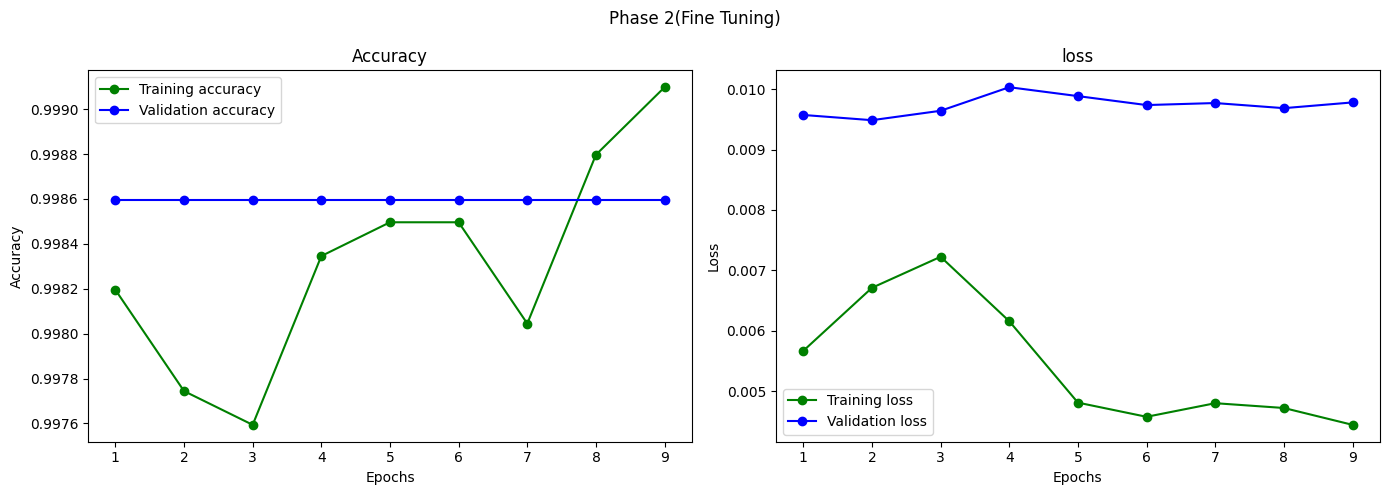

In [29]:
plot_history(history2, 'Phase 2(Fine Tuning)')

In [30]:
history_data_2 = {
    'accuracy': history2.history['accuracy'],
    'val_accuracy': history2.history['val_accuracy'],
    'loss': history2.history['loss'],
    'val_loss': history2.history['val_loss']
}

with open('/content/drive/MyDrive/CapStone_Tomatao/new/models/history2.json', 'w') as f:
    json.dump(history_data_2, f)

print('History saved')

History saved


In [ ]:
with open('/content/drive/MyDrive/CapStone_Tomatao/new/models/history2.json', 'r') as f:
    history_data = json.load(f)

In [31]:
@tf.keras.utils.register_keras_serializable()
class EfficientNetPreprocessing(tf.keras.layers.Layer):
  def call(self, x):
    return tf.keras.applications.efficientnet.preprocess_input(x)

phase_2 = '/content/drive/MyDrive/CapStone_Tomatao/new/models/gate_phase2.keras'

best_model = tf.keras.models.load_model(phase_2)

test_loss, test_acc = best_model.evaluate(test_ds)
print(f'Test accuracy: {test_acc*100:.2f}%')
print(f'Test loss: {test_loss:.4f}')

45/45 ━━━━━━━━━━━━━━━━━━━━ 514s 11s/step - accuracy: 0.9993 - loss: 0.0027
Test accuracy: 99.93%
Test loss: 0.0027


In [32]:
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy().flatten())

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

  Non_Tomato       1.00      1.00      1.00       750
      tomato       1.00      1.00      1.00       675

    accuracy                           1.00      1425
   macro avg       1.00      1.00      1.00      1425
weighted avg       1.00      1.00      1.00      1425



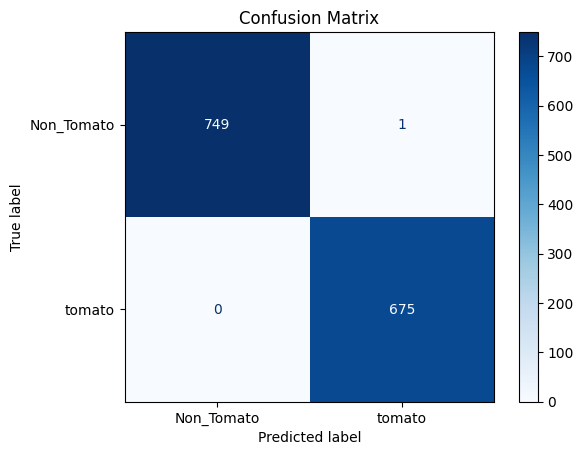

In [33]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()